## Horse Racing in HK

https://www.kaggle.com/datasets/gdaley/hkracing

https://racing.hkjc.com/racing/english/racing-info/racing_course.aspx

In [42]:
!pip3 install matplotlib
!pip3 install -U scikit-learn scipy matplotlib


     |████████████████████████████████| 7.8 MB 7.5 MB/s eta 0:00:01
     |████████████████████████████████| 33.0 MB 1.4 MB/s eta 0:00:01    |█▌                              | 1.6 MB 7.8 MB/s eta 0:00:05     |██████████████▎                 | 14.7 MB 4.6 MB/s eta 0:00:04


In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder


## Load Race/Runs data

In [4]:
data_folder = "../data/"

In [5]:
races_df = pd.read_csv(data_folder + 'races.csv')  

In [6]:
races_df.shape

(6349, 37)

In [7]:
races_df.head(5)

,race_id,date,venue,race_no,config,surface,distance,going,horse_ratings,prize,...,place_combination3,place_combination4,place_dividend1,place_dividend2,place_dividend3,place_dividend4,win_combination1,win_dividend1,win_combination2,win_dividend2
0,0,1997-06-02,ST,1,A,0,1400,GOOD TO FIRM,40-15,485000.0,...,6.0,NaN,36.5,25.5,18.0,NaN,8,121.0,NaN,NaN
1,1,1997-06-02,ST,2,A,0,1200,GOOD TO FIRM,40-15,485000.0,...,4.0,NaN,12.5,47.0,33.5,NaN,5,23.5,NaN,NaN
2,2,1997-06-02,ST,3,A,0,1400,GOOD TO FIRM,60-40,625000.0,...,13.0,NaN,23.0,23.0,59.5,NaN,11,70.0,NaN,NaN
3,3,1997-06-02,ST,4,A,0,1200,GOOD TO FIRM,120-95,1750000.0,...,10.0,NaN,14.0,24.5,16.0,NaN,5,52.0,NaN,NaN
4,4,1997-06-02,ST,5,A,0,1600,GOOD TO FIRM,60-40,625000.0,...,1.0,NaN,15.5,28.0,17.5,NaN,2,36.5,NaN,NaN


In [8]:
races_df['date'].describe()

count           6349
unique           683
top       2000-09-17
freq              11
Name: date, dtype: object

In [15]:
print("No of unique races: {}".format(races_df['race_id'].nunique()))
print("Min date: {} & Max date: {}".format(races_df['date'].min(), races_df['date'].max()))

No of unique races: 6349
Min date: 1997-06-02 & Max date: 2005-08-28


## Load Runs

In [171]:
runs_df = pd.read_csv(data_folder + 'runs.csv')  

In [172]:
runs_df.shape

(79447, 37)

In [173]:
runs_df.head(5)

,race_id,horse_no,horse_id,result,won,lengths_behind,horse_age,horse_country,horse_type,horse_rating,...,time2,time3,time4,time5,time6,finish_time,win_odds,place_odds,trainer_id,jockey_id
0,0,1,3917,10,0.0,8.00,3,AUS,Gelding,60,...,21.59,23.86,24.62,NaN,NaN,83.92,9.7,3.7,118,2
1,0,2,2157,8,0.0,5.75,3,NZ,Gelding,60,...,21.99,23.30,23.70,NaN,NaN,83.56,16.0,4.9,164,57
2,0,3,858,7,0.0,4.75,3,NZ,Gelding,60,...,21.59,23.90,24.22,NaN,NaN,83.40,3.5,1.5,137,18
3,0,4,1853,9,0.0,6.25,3,SAF,Gelding,60,...,21.83,23.70,24.00,NaN,NaN,83.62,39.0,11.0,80,59
4,0,5,2796,6,0.0,3.75,3,GB,Gelding,60,...,21.75,23.22,23.50,NaN,NaN,83.24,50.0,14.0,9,154


## Let's explore runs dataset

In [13]:
print("No of unique horses: {}".format(runs_df['horse_id'].nunique()))
print("No of unique jockeys: {}".format(runs_df['jockey_id'].nunique()))
print("No of unique races: {}".format(runs_df['race_id'].nunique()))

No of unique horses: 4405
No of unique jockeys: 186
No of unique races: 6348


## Plot horse age distribution

In [16]:
horse_age = runs_df[['horse_age']].to_numpy()

In [23]:
print("Mean of horse age: {} & std: {}".format(np.mean(horse_age), np.std(horse_age)))

Mean of horse age: 3.3393457273402394 & std: 0.8767577529592699


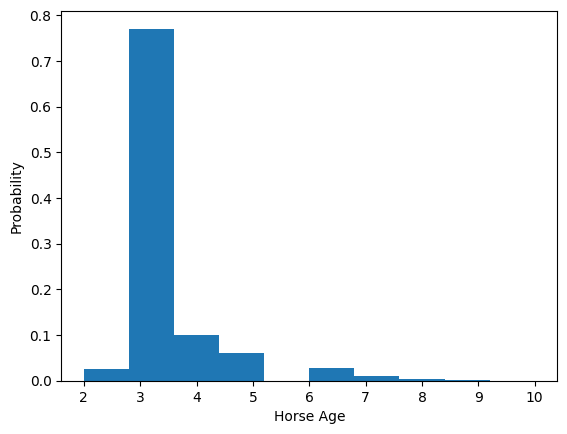

In [22]:
%matplotlib inline
# Histogram: 
# Bin it 
n, bin_edges = np.histogram(horse_age, 10) 
# Normalize it, so that every bins value gives the probability of that bin 
bin_probability = n/float(n.sum()) 
# Get the mid points of every bin 
bin_middles = (bin_edges[1:]+bin_edges[:-1])/2. 
# Compute the bin-width 
bin_width = bin_edges[1]-bin_edges[0] 
# Plot the histogram as a bar plot 

plt.bar(bin_middles, bin_probability, width=bin_width) 
plt.ylabel('Probability') 
plt.xlabel('Horse Age');


In [32]:
runs_df.dtypes

race_id              int64
horse_no             int64
horse_id             int64
result               int64
won                float64
lengths_behind     float64
horse_age            int64
horse_country       object
horse_type          object
horse_rating         int64
horse_gear          object
declared_weight    float64
actual_weight        int64
draw                 int64
position_sec1        int64
position_sec2        int64
position_sec3        int64
position_sec4      float64
position_sec5      float64
position_sec6      float64
behind_sec1        float64
behind_sec2        float64
behind_sec3        float64
behind_sec4        float64
behind_sec5        float64
behind_sec6        float64
time1              float64
time2              float64
time3              float64
time4              float64
time5              float64
time6              float64
finish_time        float64
win_odds           float64
place_odds         float64
trainer_id           int64
jockey_id            int64
d

In [33]:
runs_df['horse_country']=runs_df['horse_country'].astype('category')


In [40]:
runs_df['horse_country'].unique()

['AUS', 'NZ', 'SAF', 'GB', 'USA', ..., 'JPN', 'BRZ', 'GR', 'ITY', 'SPA']
Length: 17
Categories (16, object): ['ARG', 'AUS', 'BRZ', 'CAN', ..., 'SAF', 'SPA', 'USA', 'ZIM']

In [45]:
country_encoder = LabelEncoder()

country_encoder.fit(runs_df['horse_country'])

country_values = country_encoder.transform(runs_df['horse_country'])

In [46]:
country_values

array([ 1, 11, 11, ..., 11,  1,  8])

In [47]:
np.unique(country_values)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16])

In [48]:
country_values.shape

(79447,)

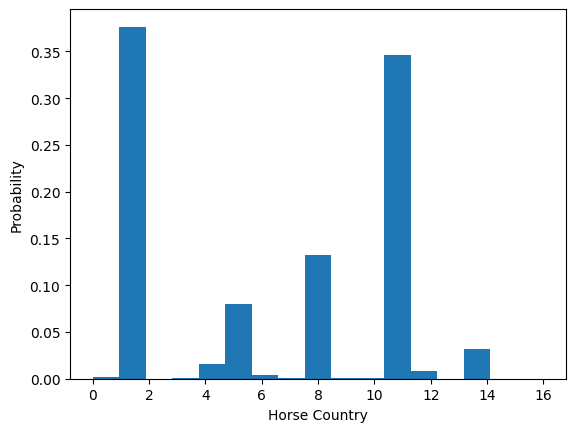

In [49]:
%matplotlib inline
# Histogram: 
# Bin it 
n, bin_edges = np.histogram(country_values, 17) 
# Normalize it, so that every bins value gives the probability of that bin 
bin_probability = n/float(n.sum()) 
# Get the mid points of every bin 
bin_middles = (bin_edges[1:]+bin_edges[:-1])/2. 
# Compute the bin-width 
bin_width = bin_edges[1]-bin_edges[0] 
# Plot the histogram as a bar plot 

plt.bar(bin_middles, bin_probability, width=bin_width) 
plt.ylabel('Probability') 
plt.xlabel('Horse Country');

In [58]:
print("Country mapping:")
for country_id in np.unique(country_values):
    print("Id: {} --> name: {}".format(country_id, country_encoder.inverse_transform([country_id])[0]))


Country mapping:
Id: 0 --> name: ARG
Id: 1 --> name: AUS
Id: 2 --> name: BRZ
Id: 3 --> name: CAN
Id: 4 --> name: FR
Id: 5 --> name: GB
Id: 6 --> name: GER
Id: 7 --> name: GR
Id: 8 --> name: IRE
Id: 9 --> name: ITY
Id: 10 --> name: JPN
Id: 11 --> name: NZ
Id: 12 --> name: SAF
Id: 13 --> name: SPA
Id: 14 --> name: USA
Id: 15 --> name: ZIM
Id: 16 --> name: nan


## Won probability of a Horse

In [59]:
horse_id = runs_df[['horse_id']].to_numpy()
won = runs_df[['won']].to_numpy()

In [67]:
# compute plays and wins per horse id
plays = {}
wins = {}

for hid, win in zip(horse_id, won):
    hid = hid[0]
    try:
        plays[hid] += 1
    except KeyError:
        plays[hid] = 1
    try:
        wins[hid] += win[0]
    except KeyError:
        wins[hid] = win[0]

In [68]:
plays[0]

39

In [69]:
wins[0]

8.0

In [73]:
# Compute probability of win

horse_win_probs = {}

for hid, play_cnt in plays.items():
    horse_win_probs[hid] = 1.0*wins[hid]/play_cnt

In [74]:
horse_win_probs[0]

0.20512820512820512

In [81]:
sorted_horses_win_prob = [(k, v) for k, v in sorted(horse_win_probs.items(), key=lambda item: item[1], reverse=True)]

In [86]:
sorted_horses_win_prob[:50]

[(2375, 1.6666666666666667),
 (2419, 1.5),
 (3676, 1.5),
 (3317, 1.5),
 (3334, 1.5),
 (2873, 1.5),
 (564, 1.3636363636363635),
 (3858, 1.3333333333333333),
 (2036, 1.2857142857142858),
 (4251, 1.25),
 (3539, 1.1666666666666667),
 (41, 1.125),
 (1033, 1.0952380952380953),
 (237, 1.0909090909090908),
 (1588, 1.0833333333333333),
 (4005, 1.0769230769230769),
 (2664, 1.0),
 (755, 1.0),
 (3392, 1.0),
 (1247, 1.0),
 (1724, 1.0),
 (2550, 1.0),
 (793, 1.0),
 (2460, 1.0),
 (3081, 1.0),
 (2780, 1.0),
 (982, 1.0),
 (3045, 1.0),
 (2294, 1.0),
 (1755, 1.0),
 (1371, 1.0),
 (3218, 1.0),
 (992, 1.0),
 (2820, 1.0),
 (2270, 1.0),
 (925, 1.0),
 (3773, 1.0),
 (3384, 1.0),
 (1190, 1.0),
 (3894, 1.0),
 (1012, 1.0),
 (1210, 1.0),
 (1352, 1.0),
 (3331, 1.0),
 (1856, 1.0),
 (2513, 1.0),
 (216, 1.0),
 (1960, 0.9285714285714286),
 (3336, 0.9285714285714286),
 (1732, 0.9230769230769231)]

In [84]:
plays[2375]

3

In [85]:
wins[2375]

5.0

In [ ]:
## Horse type

In [87]:
horse_type_encoder = LabelEncoder()

horse_type_encoder.fit(runs_df['horse_type'])

horse_type_values = horse_type_encoder.transform(runs_df['horse_type'])

In [89]:
np.unique(horse_type_values)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

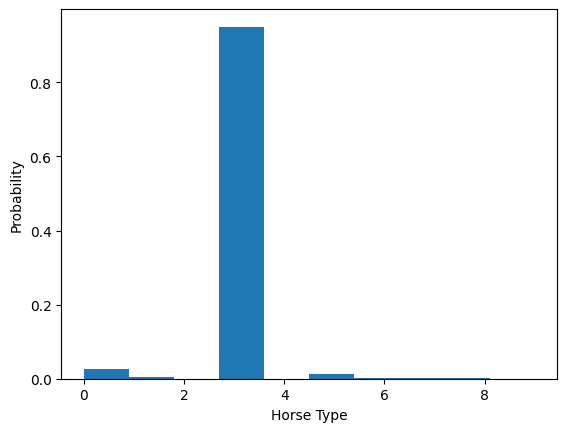

In [90]:
%matplotlib inline
# Histogram: 
# Bin it 
n, bin_edges = np.histogram(horse_type_values, 10) 
# Normalize it, so that every bins value gives the probability of that bin 
bin_probability = n/float(n.sum()) 
# Get the mid points of every bin 
bin_middles = (bin_edges[1:]+bin_edges[:-1])/2. 
# Compute the bin-width 
bin_width = bin_edges[1]-bin_edges[0] 
# Plot the histogram as a bar plot 

plt.bar(bin_middles, bin_probability, width=bin_width) 
plt.ylabel('Probability') 
plt.xlabel('Horse Type');

In [91]:
print("Horse type mapping:")
for htid in np.unique(horse_type_values):
    print("Id: {} --> name: {}".format(htid, horse_type_encoder.inverse_transform([htid])[0]))


Horse type mapping:
Id: 0 --> name: Brown
Id: 1 --> name: Colt
Id: 2 --> name: Filly
Id: 3 --> name: Gelding
Id: 4 --> name: Grey
Id: 5 --> name: Horse
Id: 6 --> name: Mare
Id: 7 --> name: Rig
Id: 8 --> name: Roan
Id: 9 --> name: nan


In [92]:
from sklearn.ensemble import RandomForestRegressor

In [93]:
runs_df.head(5)

,race_id,horse_no,horse_id,result,won,lengths_behind,horse_age,horse_country,horse_type,horse_rating,...,time2,time3,time4,time5,time6,finish_time,win_odds,place_odds,trainer_id,jockey_id
0,0,1,3917,10,0.0,8.00,3,AUS,Gelding,60,...,21.59,23.86,24.62,NaN,NaN,83.92,9.7,3.7,118,2
1,0,2,2157,8,0.0,5.75,3,NZ,Gelding,60,...,21.99,23.30,23.70,NaN,NaN,83.56,16.0,4.9,164,57
2,0,3,858,7,0.0,4.75,3,NZ,Gelding,60,...,21.59,23.90,24.22,NaN,NaN,83.40,3.5,1.5,137,18
3,0,4,1853,9,0.0,6.25,3,SAF,Gelding,60,...,21.83,23.70,24.00,NaN,NaN,83.62,39.0,11.0,80,59
4,0,5,2796,6,0.0,3.75,3,GB,Gelding,60,...,21.75,23.22,23.50,NaN,NaN,83.24,50.0,14.0,9,154


In [94]:
y = runs_df['won'].to_numpy()

In [95]:
y[:10]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [195]:
runs_df = pd.read_csv(data_folder + 'runs.csv')  

In [196]:
runs_df.isna().sum()

race_id                0
horse_no               0
horse_id               0
result                 0
won                    0
lengths_behind         0
horse_age              0
horse_country          2
horse_type             2
horse_rating           0
horse_gear             0
declared_weight        0
actual_weight          0
draw                   0
position_sec1          0
position_sec2          0
position_sec3          0
position_sec4      33221
position_sec5      69368
position_sec6      78151
behind_sec1            0
behind_sec2            0
behind_sec3            0
behind_sec4        33221
behind_sec5        69368
behind_sec6        78151
time1                  0
time2                  0
time3                  0
time4              33221
time5              69368
time6              78151
finish_time            0
win_odds               0
place_odds          3735
trainer_id             0
jockey_id              0
dtype: int64

In [197]:
runs_df.dtypes

race_id              int64
horse_no             int64
horse_id             int64
result               int64
won                float64
lengths_behind     float64
horse_age            int64
horse_country       object
horse_type          object
horse_rating         int64
horse_gear          object
declared_weight    float64
actual_weight        int64
draw                 int64
position_sec1        int64
position_sec2        int64
position_sec3        int64
position_sec4      float64
position_sec5      float64
position_sec6      float64
behind_sec1        float64
behind_sec2        float64
behind_sec3        float64
behind_sec4        float64
behind_sec5        float64
behind_sec6        float64
time1              float64
time2              float64
time3              float64
time4              float64
time5              float64
time6              float64
finish_time        float64
win_odds           float64
place_odds         float64
trainer_id           int64
jockey_id            int64
d

In [198]:
runs_df['horse_country'].isna()

0        False
1        False
2        False
3        False
4        False
         ...  
79442    False
79443    False
79444    False
79445    False
79446    False
Name: horse_country, Length: 79447, dtype: bool

In [199]:
#runs_df['horse_country'] = runs_df['horse_country'].astype(str) 

In [200]:
runs_df['horse_country'] = runs_df['horse_country'].fillna('-1') 

In [201]:
runs_df['horse_country']

0        AUS
1         NZ
2         NZ
3        SAF
4         GB
        ... 
79442    AUS
79443     NZ
79444     NZ
79445    AUS
79446    IRE
Name: horse_country, Length: 79447, dtype: object

In [202]:
runs_df['horse_type'] = runs_df['horse_type'].fillna('-1') 

In [203]:
Very_Hight_Position = 10000
runs_df['position_sec4'] = runs_df['position_sec4'].fillna(Very_Hight_Position)
runs_df['position_sec5'] = runs_df['position_sec5'].fillna(Very_Hight_Position) 
runs_df['position_sec6'] = runs_df['position_sec6'].fillna(Very_Hight_Position) 


In [204]:
runs_df.isna().sum()

race_id                0
horse_no               0
horse_id               0
result                 0
won                    0
lengths_behind         0
horse_age              0
horse_country          0
horse_type             0
horse_rating           0
horse_gear             0
declared_weight        0
actual_weight          0
draw                   0
position_sec1          0
position_sec2          0
position_sec3          0
position_sec4          0
position_sec5          0
position_sec6          0
behind_sec1            0
behind_sec2            0
behind_sec3            0
behind_sec4        33221
behind_sec5        69368
behind_sec6        78151
time1                  0
time2                  0
time3                  0
time4              33221
time5              69368
time6              78151
finish_time            0
win_odds               0
place_odds          3735
trainer_id             0
jockey_id              0
dtype: int64

In [205]:
Very_Hight_Behind_Sec = 100000
runs_df['behind_sec4'] = runs_df['behind_sec4'].fillna(Very_Hight_Behind_Sec)
runs_df['behind_sec5'] = runs_df['behind_sec5'].fillna(Very_Hight_Behind_Sec) 
runs_df['behind_sec6'] = runs_df['behind_sec6'].fillna(Very_Hight_Behind_Sec) 

In [206]:
Very_Hight_Time = 10000
runs_df['time4'] = runs_df['time4'].fillna(Very_Hight_Time)
runs_df['time5'] = runs_df['time5'].fillna(Very_Hight_Time) 
runs_df['time6'] = runs_df['time6'].fillna(Very_Hight_Time) 

In [207]:
Very_Hight_Odd = 10000
runs_df['place_odds'] = runs_df['place_odds'].fillna(Very_Hight_Odd)

In [208]:
runs_df.isna().sum()

race_id            0
horse_no           0
horse_id           0
result             0
won                0
lengths_behind     0
horse_age          0
horse_country      0
horse_type         0
horse_rating       0
horse_gear         0
declared_weight    0
actual_weight      0
draw               0
position_sec1      0
position_sec2      0
position_sec3      0
position_sec4      0
position_sec5      0
position_sec6      0
behind_sec1        0
behind_sec2        0
behind_sec3        0
behind_sec4        0
behind_sec5        0
behind_sec6        0
time1              0
time2              0
time3              0
time4              0
time5              0
time6              0
finish_time        0
win_odds           0
place_odds         0
trainer_id         0
jockey_id          0
dtype: int64

In [209]:
lengths_behind = runs_df['lengths_behind'].to_numpy()
horse_age = runs_df['horse_age'].to_numpy()
horse_country = runs_df['horse_country'].to_numpy()
horse_type = runs_df['horse_type'].to_numpy()
horse_rating = runs_df['horse_rating'].to_numpy()
horse_gear = runs_df['horse_gear'].to_numpy()
declared_weight = runs_df['declared_weight'].to_numpy()
actual_weight = runs_df['actual_weight'].to_numpy()
draw = runs_df['draw'].to_numpy()
position_sec1 = runs_df['position_sec1'].to_numpy()
position_sec2 = runs_df['position_sec2'].to_numpy()
position_sec3 = runs_df['position_sec3'].to_numpy()
position_sec4 = runs_df['position_sec4'].to_numpy()
position_sec5 = runs_df['position_sec5'].to_numpy()
position_sec6 = runs_df['position_sec6'].to_numpy()
behind_sec1 = runs_df['behind_sec1'].to_numpy()
behind_sec2 = runs_df['behind_sec2'].to_numpy()
behind_sec3 = runs_df['behind_sec3'].to_numpy()
behind_sec4 = runs_df['behind_sec4'].to_numpy()
behind_sec5 = runs_df['behind_sec5'].to_numpy()
behind_sec6 = runs_df['behind_sec6'].to_numpy()

time1 = runs_df['time1'].to_numpy()
time2 = runs_df['time2'].to_numpy()
time3 = runs_df['time3'].to_numpy()
time4 = runs_df['time4'].to_numpy()
time5 = runs_df['time5'].to_numpy()
time6 = runs_df['time6'].to_numpy()

finish_time = runs_df['finish_time'].to_numpy()
win_odds = runs_df['win_odds'].to_numpy()
place_odds = runs_df['place_odds'].to_numpy()


In [210]:
lengths_behind[:5]

array([8.  , 5.75, 4.75, 6.25, 3.75])

In [336]:
feature_names = []

In [337]:
# This is dependent variabl!!
# x1 = lengths_behind
# feature_names.append('lengths_behind')

In [338]:
horse_age[:5]

array([3, 3, 3, 3, 3])

In [339]:
x2 = horse_age
feature_names.append('horse_age')

## Encode categorical features

In [340]:
country_encoder = LabelEncoder()

country_encoder.fit(horse_country)

horse_country_encoded = country_encoder.transform(horse_country)

In [341]:
horse_country_encoded[:5]

array([ 2, 12, 12, 13,  6])

In [342]:
horse_country_encoded.shape

(79447,)

In [343]:
x3 = horse_country_encoded
feature_names.append('horse_country')

In [344]:
horse_type[:5]

array(['Gelding', 'Gelding', 'Gelding', 'Gelding', 'Gelding'],
      dtype=object)

In [345]:
encoder = LabelEncoder()

encoder.fit(horse_type)

x_encoded = encoder.transform(horse_type)

In [346]:
x_encoded[:4]

array([4, 4, 4, 4])

In [347]:
x4 = x_encoded
feature_names.append('horse_type')

In [348]:
horse_rating[:8]

array([60, 60, 60, 60, 60, 60, 60, 60])

In [349]:
encoder = LabelEncoder()

encoder.fit(horse_rating)

x_encoded = encoder.transform(horse_rating)

In [350]:
x_encoded[:5]

array([48, 48, 48, 48, 48])

In [351]:
np.unique(x_encoded)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124])

In [352]:
x5 = x_encoded
feature_names.append('horse_rating')

In [353]:
def categorize(arr):
    encoder = LabelEncoder()

    encoder.fit(arr)

    return encoder.transform(arr)

In [354]:
horse_gear[:5]

array(['--', '--', '--', '--', '--'], dtype=object)

In [355]:
x6 = categorize(horse_gear)
feature_names.append('horse_gear')

In [356]:
x6[:5]

array([0, 0, 0, 0, 0])

In [357]:
declared_weight[:5]

array([1020.,  980., 1082., 1118.,  972.])

In [358]:
x7 = declared_weight
feature_names.append('declared_weight')

In [359]:
actual_weight[:5]

array([133, 133, 132, 127, 131])

In [360]:
x8 = actual_weight
feature_names.append('actual_weight')

In [361]:
draw[:5]

array([ 7, 12,  8, 13, 14])

In [362]:
x9 = draw
feature_names.append('draw')

In [363]:
position_sec1[:5]

array([ 6, 12,  3,  8, 13])

In [364]:
x10 = position_sec1
x11 = position_sec2
x12 = position_sec3
x13 = position_sec4
x14 = position_sec5
x15 = position_sec6

feature_names.append('position_sec1')
feature_names.append('position_sec2')
feature_names.append('position_sec3')
feature_names.append('position_sec4')
feature_names.append('position_sec5')
feature_names.append('position_sec6')

In [365]:
behind_sec1[:5]

array([2.  , 6.5 , 1.  , 3.5 , 7.75])

In [366]:
x16 = behind_sec1
x17 = behind_sec2
x18 = behind_sec3
x19 = behind_sec4
x20 = behind_sec5
x21 = behind_sec6

feature_names.append('behind_sec1')
feature_names.append('behind_sec2')
feature_names.append('behind_sec3')
feature_names.append('behind_sec4')
feature_names.append('behind_sec5')
feature_names.append('behind_sec6')

In [367]:
time1[:5]

array([13.85, 14.57, 13.69, 14.09, 14.77])

In [368]:
x22 = time1
x23 = time2
x24 = time3
x25 = time4
x26 = time5
x27 = time6

feature_names.append('time1')
feature_names.append('time2')
feature_names.append('time3')
feature_names.append('time4')
feature_names.append('time5')
feature_names.append('time6')

In [369]:
finish_time[:5]

array([83.92, 83.56, 83.4 , 83.62, 83.24])

In [370]:
x28 = finish_time
feature_names.append('finish_time')

In [371]:
win_odds[:5]

array([ 9.7, 16. ,  3.5, 39. , 50. ])

In [372]:
x29= win_odds
feature_names.append('win_odds')

In [373]:
place_odds[:5]

array([ 3.7,  4.9,  1.5, 11. , 14. ])

In [374]:
x30 = place_odds
feature_names.append('place_odds')

In [375]:
x1.shape

(79447,)

In [376]:
y.shape

(79447,)

In [377]:
X = np.column_stack((x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,
                     x23,x24,x25,x26,x27, x28, x29, x30))

In [378]:
len(feature_names)

29

In [379]:
X.shape

(79447, 29)

In [380]:
rf = RandomForestRegressor(max_depth=2, random_state=0)

In [381]:
rf.fit(X, y)

RandomForestRegressor(max_depth=2, random_state=0)

In [382]:
fet_imp = rf.feature_importances_

In [383]:
fet_imp.shape

(29,)

<BarContainer object of 29 artists>

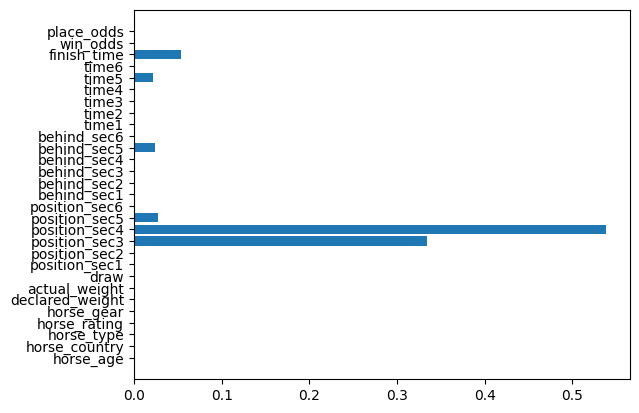

In [384]:
plt.barh(feature_names, rf.feature_importances_)


In [2]:
## I think lots of above features arre also dependent variables since they are position measurements during the game!!!



# HK Horse Racing Data Set

## downloaded from:  https://www.kaggle.com/datasets/gdaley/hkracing

### races.csv

Each line describes the condition of an individual race.

race_id - unique identifier for the race

date - date of the race, in YYYY-MM-DD format (note that the dates given have been obscured and are not the real ones, although the durations between each race should be correct)

venue - a 2-character string, representing which of the 2 race courses this race took place at: ST = Shatin, HV = Happy Valley

race_no - race number of the race in the day's meeting

config - race track configuration, mostly related to the position of the inside rail. For more details, see the HKJC website.

surface - a number representing the type of race track surface: 1 = dirt, 0 = turf

distance - distance of the race, in metres

going - track condition. For more details, see the HKJC website.

horse_ratings - the range of horse ratings that may participate in this race

prize - the winning prize, in HK Dollars

race_class - a number representing the class of the race

sec_time1 - time taken by the leader of the race to reach the end of the end of the 1st sectional point (sec)

sec_time2 - time taken by the leader of the race to reach the end of the 2nd sectional point (sec)

sec_time3 - time taken by the leader of the race to reach the end of the 3rd sectional point (sec)

sec_time4 - time taken by the leader of the race to reach the end of the 4th sectional point, if any (sec)

sec_time5 - time taken by the leader of the race to reach the end of the 5th sectional point, if any (sec)

sec_time6 - time taken by the leader of the race to reach the end of the fourth sectional point, if any (sec)

sec_time7 - time taken by the leader of the race to reach the end of the fourth sectional point, if any (sec)

time1 - time taken by the leader of the race in the 1st section only (sec)

time2 - time taken by the leader of the race in the 2nd section only (sec)

time3 - time taken by the leader of the race in the 3rd section only (sec)

time4 - time taken by the leader of the race in the 4th section only, if any (sec)

time5 - time taken by the leader of the race in the 5th section only, if any (sec)

time6 - time taken by the leader of the race in the 6th section only, if any (sec)

time7 - time taken by the leader of the race in the 7th section only, if any (sec)

place_combination1 - placing horse no (1st)

place_combination2 - placing horse no (2nd)

place_combination3 - placing horse no (3rd)

place_combination4 - placing horse no (4th)

placedividend1 - placing dividend paid (for placecombination1)

placedividend2 - placing dividend paid (for placecombination2)

placedividend3 - placing dividend paid (for placecombination2)

placedividend4 - placing dividend paid (for placecombination2)

win_combination1 - winning horse no

windividend1 - winning dividend paid (for wincombination1)

win_combination2 - joint winning horse no, if any

windividend2 - winning dividend paid (for wincombination2, if any)

### runs.csv
Each line describes the characteristics of one horse run, in one of the races given in races.csv.

race_id - unique identifier for the race

horse_no - the number assigned to this horse, in the race

horse_id - unique identifier for this horse

result - finishing position of this horse in the race

won - whether horse won (1) or otherwise (0)

lengths_behind - finishing position, as the number of horse lengths behind the winner

horse_age - current age of this horse at the time of the race

horse_country - country of origin of this horse

horse_type - sex of the horse, e.g. 'Gelding', 'Mare', 'Horse', 'Rig', 'Colt', 'Filly'

horse_rating - rating number assigned by HKJC to this horse at the time of the race

horse_gear - string representing the gear carried by the horse in the race. An explanation of the codes used may be found on the HKJC website.

declared_weight - declared weight of the horse and jockey, in lbs

actual_weight - actual weight carried by the horse, in lbs

draw - post position number of the horse in this race

position_sec1 - position of this horse (ranking) in section 1 of the race

position_sec2 - position of this horse (ranking) in section 2 of the race

position_sec3 - position of this horse (ranking) in section 3 of the race

position_sec4 - position of this horse (ranking) in section 4 of the race, if any

position_sec5 - position of this horse (ranking) in section 5 of the race, if any

position_sec6 - position of this horse (ranking) in section 6 of the race, if any

behind_sec1 - position of this horse (lengths behind leader) in section 1 of the race

behind_sec2 - position of this horse (lengths behind leader) in section 2 of the race

behind_sec3 - position of this horse (lengths behind leader) in section 3 of the race

behind_sec4 - position of this horse (lengths behind leader) in section 4 of the race, if any

behind_sec5 - position of this horse (lengths behind leader) in section 5 of the race, if any

behind_sec6 - position of this horse (lengths behind leader) in section 6 of the race, if any

time1 - time taken by the horse to pass through the 1st section of the race (sec)

time2 - time taken by the horse to pass through the 2nd section of the race (sec)

time3 - time taken by the horse to pass through the 3rd section of the race (sec)

time4 - time taken by the horse to pass through the 4th section of the race, if any (sec)

time5 - time taken by the horse to pass through the 5th section of the race, if any (sec)

time6 - time taken by the horse to pass through the 6th section of the race, if any (sec)

finish_time - finishing time of the horse in this race (sec)

win_odds - win odds for this horse at start of race

place_odds - place (finishing in 1st, 2nd or 3rd position) odds for this horse at start of race

trainer_id - unique identifier of the horse's trainer at the time of the race

jockey_id - unique identifier of the jockey riding the horse in this race

## Features

The following info are the possible Horse Assesment Attributes that can contribute to the odds of winning. Those info is nothing but the summary of the following documents:

* https://res.hkjc.com/campaigns/wp-content/uploads/sites/406/Racing101_Eng.pdf 
* https://res.hkjc.com/campaigns/wp-content/uploads/sites/406/Racing201_Eng.pdf 
* https://res.hkjc.com/campaigns/wp-content/uploads/sites/406/Racing202_Eng.pdf

More info about hongkong horse racing can be found in this url: 
* https://racing.hkjc.com/racing/english/index.aspx

Table of contents:

* 1: Recent Performance 
* 2 ~ 5: Track and Distance: 
* 6 ~ 7: Jockey and Trainer 
* 8~9: Class and Weight 
* 10: condition 
* 11: pace and trend

### 1. Recent Performance

    Long time ago history may NOT be that useful. The recent history (e.g. past 6 races) should do good.

    * very good: Has won once more good: Results are improving in the last 3-4 races/has finished in a 
    first-3 position. 
    * so so: mostly finished between 4th and 6th bad: Mostly finished in 7th position or lower/ results 
        are declining in the last 3-4 races 
    * very bad: Mostly finished in 10th position or lower
    


### 2.  venue (the place where the race takes place)

    There are two places in hk: Shatin(st) and Happy Valley(hv)


### 3.  types of track

    two types of tracks: grass and dirt. horses performance can be significantly affected by types of 
    tracks Each horse may perform particularly well over a specific track types.
    

### 4.  distance

    Every horse has his favourite distance.

    Some hourse are good at short distance but not good performers on long distance. Similar to different 
    performance in long/middle/short distance for a human runner. Is Usain Bolt also a top Marathon runner? 
    probablly not.
    


    Distance are classified into short/mid/long distances:

    4.1 Shatin + turf(grass track)

         - short distance: 1000m, 1200m, 1400m
         - mid distance: 1600m, 1800m
         - long distance: 2000m, 2400m

    4.2 Shatin + dirt(all_weather track)

         - short distance: 1200m
         - mid distance: 1650m, 1800m

    4.3 Happy Valley + turf(grass track)

         - short distance: 1000m, 1200m
         - mid distance: 1650m, 1800m
         - long distance: 2200m
 
 
### 5.  going(condition of the track)

    - good to firm
    - good to yielding 
    - good, yielding 
    - yielding to soft 
    - soft 
    - fast 
    - wet slow
    - wet fast
    

### 6.  jockey

    A jockey's competence can be reflected in their ranking, win% and first-3%.
    

### 7.  trainer

    noticed that some trainers may perform well on particular track surface.

    Also, Some trainers may have a lower overall ranking, but have good performance on their favourite tracks.
    

### 8.  draw

    The draw refers to a horse's position in the starting gate.

    Generally, the smaller the draw number, the closer the runner is to the inside rail hence the 
    shorter distance to be covered at the turns and has a slight advantege over horses with bigger draw.

    Each runner's draw number is randomly assigned by computer a couple of days before the race.

    Horse number != Draw number(Horse Number 1 can be drawn 14).

    Study the win% asnd first% of each draw over each track and distance.

    Impact of draw will be different according to a horse's running style:

    starting with an inside draw has an advantege especially for front-runners

    A late-finisher may have an advantege if he starts with a middle draw

    For ST grass 1000M straight, horse that start from an outside draw have a competitive advantege 
    because their is less damage to the track by the GrandStandard.

    Last but not least, watch closely when there is any chance of draw from the last start.
    

### 9.  class and weight

    9.1 ranking(class) system:

     -   5 rankings in total which range from class 1(the highest) to class 5(the lowest) 

     -   All the horses participate in a race MUST belong to the same class.

     -   Use points to categorize horses'a rankings. Higher points means higher rank.

     -   Initially, 52 points are given to a horse for its first race.

     -   Points can go up/down if win/lose.

         class 1: > 85 points
         class 2: > 80 ~ 100points
         class 3: > 60-80 points
         class 4: > 40-60 points
         class 5: > 0-40 points
         
    9.2 weight

     In order to make races for fair and excieting to watch, horses are required to carry weight during 
     a race. The weight that a horse carry is reduced/increased based on this previous results. 

     9.2.1   Weight reduced

             if weight reduced after a loss in the same class:
                 if finished in a first-6 position(in recent start results):
                     higher first-3 chance
                 elif Did not finish in a first-6 position(in recent start results):
                     lower first-3 chance

             if weight reduced after a win and is promoted in class:
                 if won by 1 lenght of above(in recent start results):
                     higher first-3 chance
                 elif won by less than 1 length(in recent start results):
                     lower first-3 chance

             ?? What does "length" mean here?
             

     9.2.2   Weight increased:

             if weight increased after winning a race in the same class:
                 if won by 1 length or above(in recent start results):
                     higher first-3 chance
                 elif won by less than 1 length(in recent start results):
                     lower first-3 chance

             if weight increased after losing a race and a drop in class:
                 if finished in a first-6 position(in recent start results):
                     higher first-3 chance
                 elif Did not finish in a first-6 position (in recent start results):
                     lower first-3 chance
                     
                     
### 10. Condition

    10.1 A horse' weight:

    if abs(cur_weight - last_weight) < 20 lbs:
        condition should be maintained
    elif abs(cur_weight - max(weight_of_first_3_position)) < 10 lbs:
        condition should be maintained
    else:
        condition may have dropped
        
        
    10.2 A horse's parade

    Good: Well-toned, muscles, eager eyes, calm and relaxed
    Bad:  Edgy, heavy, sweating, bucking frequently
    10.3 A horse's last barrier trial

    Good symptons: 

    1.  The horse finished the barrier trial after 
        a relaxed run without pressure

    2.  The horse continues to accelerate after the finishing line, showing he has a strong 
        desire to win.

    3.  The horse finishes close to other high-rated horses, reflecting that he is in top form.

    4.  The finishing time is much faster than another barrier trial over the same distance on 
        the same day, reflecting that the horse has set a high standard. 
        
        
### 11. pace and trend

    Fast pace race favorites late-finished rather than front-runners Slow pace race favorites 
    front-finished rather than late-runners Normal pace race favorites no one.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load races data

In [6]:
races_df = pd.read_csv(r"../data/races.csv", delimiter=",", header=0, index_col='race_id')
races_df = races_df[['date', 'venue', 'config', 'surface', 'distance', 'going', 'race_class', 'prize']]
races_df.head()

,date,venue,config,surface,distance,going,race_class,prize
race_id,,,,,,,,
0,1997-06-02,ST,A,0,1400,GOOD TO FIRM,5,485000.0
1,1997-06-02,ST,A,0,1200,GOOD TO FIRM,5,485000.0
2,1997-06-02,ST,A,0,1400,GOOD TO FIRM,4,625000.0
3,1997-06-02,ST,A,0,1200,GOOD TO FIRM,1,1750000.0
4,1997-06-02,ST,A,0,1600,GOOD TO FIRM,4,625000.0


### Load runs data

In [7]:
runs_df = pd.read_csv(r"../data/runs.csv", delimiter=",", header=0, index_col='race_id')
runs_df = runs_df[['horse_id', 'result', 'win_odds', 'finish_time', 'draw', 'horse_age', 'horse_rating', 'declared_weight', 'actual_weight', 'jockey_id', 'trainer_id']]
runs_df.head(5)

,horse_id,result,win_odds,finish_time,draw,horse_age,horse_rating,declared_weight,actual_weight,jockey_id,trainer_id
race_id,,,,,,,,,,,
0,3917,10,9.7,83.92,7,3,60,1020.0,133,2,118
0,2157,8,16.0,83.56,12,3,60,980.0,133,57,164
0,858,7,3.5,83.40,8,3,60,1082.0,132,18,137
0,1853,9,39.0,83.62,13,3,60,1118.0,127,59,80
0,2796,6,50.0,83.24,14,3,60,972.0,131,154,9


## First we need to verify the statement: 

### "The public's implied probability estimates generally correspond well with the actual frequcncices of winning. "

In [8]:
# We first need to calculate the expected winning odds for a specific horse
horse_ids = runs_df['horse_id'].unique()
horse_ids.sort()

df = pd.DataFrame(columns=['horse_id', 'win_freq', "win_estimated", 'races_played'])
df['horse_id'] = df['horse_id'].astype('int')
df['races_played'] = df['races_played'].astype('int')
df.set_index('horse_id', inplace=True)

# calculate each horse's winning frequencies
for horse_id in horse_ids:
    total_races_df = runs_df[runs_df.horse_id == horse_id]
    win_count = (total_races_df['result'] == 1).sum()
    win_freq = win_count / len(total_races_df)
    df.loc[horse_id] = [win_freq, 0.0, len(total_races_df)]

In [9]:
# calculate each horse's expected freqneucies
run_ids = runs_df.index.unique()
for run_id in run_ids:
    runs_small_df = runs_df[runs_df.index==run_id]
    
    total_percent = 0.0
    for index, row in runs_small_df.iterrows():                  
        total_percent += 1 / row['win_odds']
    
    for index, row in runs_small_df.iterrows():
        horse_id = row['horse_id']
        win_odds = row['win_odds']
        
        win_expected = 1 / win_odds / total_percent
        df.loc[horse_id]['win_estimated'] += win_expected / df.loc[horse_id].races_played

In [10]:
df.loc[(df['win_freq'] >= 0.0) & (df['win_freq'] < 0.01)]

,win_freq,win_estimated,races_played
horse_id,,,
3,0.0,0.010003,3.0
5,0.0,0.011766,2.0
6,0.0,0.038793,1.0
9,0.0,0.008138,5.0
10,0.0,0.032609,1.0
...,...,...,...
4392,0.0,0.015215,5.0
4394,0.0,0.038626,18.0
4395,0.0,0.051955,13.0


In [11]:
df.loc[(df['win_freq'] >= 0.01) & (df['win_freq'] < 0.025)]

,win_freq,win_estimated,races_played
horse_id,,,
280,0.020833,0.066637,48.0
571,0.020833,0.084038,48.0
928,0.020833,0.098072,48.0
974,0.020000,0.079264,50.0
1063,0.024390,0.106397,41.0
1556,0.022222,0.062771,45.0
1722,0.020000,0.058030,50.0
1898,0.022727,0.089314,44.0
1908,0.020408,0.110651,49.0


In [12]:
df.loc[(df['win_freq'] >= 0.025) & (df['win_freq'] < 0.05)]

,win_freq,win_estimated,races_played
horse_id,,,
1,0.038462,0.124144,26.0
4,0.034483,0.055017,29.0
25,0.034483,0.061703,29.0
26,0.041667,0.029595,48.0
62,0.040000,0.082525,25.0
...,...,...,...
4359,0.044444,0.059147,45.0
4364,0.032258,0.088622,31.0
4376,0.043478,0.100063,23.0


In [13]:
df.loc[(df['win_freq'] >= 0.05) & (df['win_freq'] < 0.1)]

,win_freq,win_estimated,races_played
horse_id,,,
2,0.060606,0.078049,33.0
8,0.052632,0.091147,19.0
16,0.090909,0.101942,11.0
18,0.096774,0.088192,31.0
22,0.071429,0.065985,14.0
...,...,...,...
4383,0.066667,0.047255,15.0
4384,0.068966,0.082276,29.0
4390,0.058824,0.056305,17.0


In [14]:
df.loc[(df['win_freq'] >= 0.1) & (df['win_freq'] < 0.15)]

,win_freq,win_estimated,races_played
horse_id,,,
0,0.102564,0.073447,39.0
7,0.133333,0.090279,15.0
15,0.133333,0.099503,30.0
19,0.133333,0.098748,15.0
24,0.107143,0.133087,28.0
...,...,...,...
4370,0.105263,0.061495,19.0
4386,0.142857,0.089044,21.0
4388,0.121951,0.106767,41.0


In [15]:
df.loc[(df['win_freq'] >= 0.15) & (df['win_freq'] < 0.2)]

,win_freq,win_estimated,races_played
horse_id,,,
11,0.166667,0.238689,6.0
30,0.181818,0.163411,22.0
59,0.187500,0.127944,16.0
65,0.156250,0.118237,32.0
72,0.190476,0.053514,21.0
...,...,...,...
4367,0.181818,0.194428,11.0
4368,0.171429,0.101286,35.0
4399,0.181818,0.089375,11.0


In [16]:
df.loc[(df['win_freq'] >= 0.2) & (df['win_freq'] < 0.25)]

,win_freq,win_estimated,races_played
horse_id,,,
84,0.200000,0.253035,10.0
92,0.200000,0.083072,5.0
123,0.200000,0.130371,20.0
144,0.200000,0.039044,10.0
154,0.217391,0.185756,23.0
...,...,...,...
4256,0.200000,0.042968,5.0
4264,0.227273,0.113937,22.0
4266,0.214286,0.149758,14.0


In [17]:
df.loc[(df['win_freq'] >= 0.25) & (df['win_freq'] < 0.3)]

,win_freq,win_estimated,races_played
horse_id,,,
17,0.260870,0.154248,23.0
109,0.250000,0.236107,4.0
130,0.263158,0.169750,19.0
160,0.272727,0.226395,11.0
180,0.296296,0.116510,27.0
...,...,...,...
4243,0.272727,0.141499,11.0
4362,0.285714,0.193017,7.0
4363,0.250000,0.052818,4.0


In [18]:
df.loc[(df['win_freq'] >= 0.3) & (df['win_freq'] < 0.4)]

,win_freq,win_estimated,races_played
horse_id,,,
73,0.363636,0.198338,11.0
97,0.333333,0.158911,6.0
218,0.312500,0.267520,16.0
414,0.307692,0.295247,13.0
429,0.333333,0.093372,3.0
...,...,...,...
4141,0.368421,0.202366,19.0
4198,0.333333,0.131071,15.0
4276,0.333333,0.143952,9.0


In [19]:
df.loc[(df['win_freq'] >= 0.4)]

,win_freq,win_estimated,races_played
horse_id,,,
41,0.625000,0.438658,8.0
108,0.500000,0.243613,2.0
216,1.000000,0.061039,1.0
222,0.444444,0.164342,9.0
237,0.545455,0.194552,11.0
...,...,...,...
3858,0.666667,0.253373,6.0
3894,1.000000,0.287872,1.0
4005,0.538462,0.338974,13.0
